In [1333]:
import sqlite3
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

conn = sqlite3.connect('../../krisha.kz/db.sqlite')
query = """
SELECT * FROM flats
JOIN prices ON flats.id = prices.flat_id
"""

df = pd.read_sql_query(query, conn)
conn.close()

df['specs'] = df['specs'].apply(json.loads)

# 2. Flatten the 'specs' column into a new DataFrame
specs_expanded = pd.json_normalize(df['specs'])

# 3. Join the new columns back to your original DataFrame
df = pd.concat([df.drop('specs', axis=1), specs_expanded], axis=1)
df.drop(columns=['id', 'photo', 'flat_id', 'star', 'focus', 'date'], inplace=True)
df = df.rename(columns={'type': 'internet', 'balcony_g': 'balcony_glazing'})
df['year'] = df['year'].astype(int)

df.columns.tolist()

df.describe(include='all')

# booleans: priv_dorm, furniture, has_change, balcony_glazing

,url,room,square,city,price,lat,lon,building,complex,year,...,parking,furniture,flooring,ceiling,security,has_change,priv_dorm,balcony,balcony_glazing,phone
count,10275,10275.000000,10275,10275,1.027500e+04,10275.000000,10275.000000,9744,8431,10275.000000,...,6767,5099,4473,9529,4564,9778,8985,5165,2478,2013
unique,10275,NaN,4213,1,NaN,NaN,NaN,4,1087,NaN,...,3,3,7,42,140,2,2,4,2,4
top,https://krisha.kz/a/show/1009899858,NaN,40 м²,Астана,NaN,NaN,NaN,монолитный,Respublika,NaN,...,паркинг,полностью,ламинат,3 м,"домофон, видеонаблюдение",Нет,нет,лоджия,да,есть возможность подключения
freq,1,NaN,209,10275,NaN,NaN,NaN,5440,165,NaN,...,6171,3609,3909,4643,1146,9290,8964,2474,2407,1145
mean,NaN,2.137908,NaN,NaN,3.933383e+07,51.120107,71.429604,NaN,NaN,2017.874745,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,0.882066,NaN,NaN,1.897378e+07,0.250343,0.284143,NaN,NaN,10.713480,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,1.000000,NaN,NaN,5.000000e+06,43.188423,57.191665,NaN,NaN,1916.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,1.000000,NaN,NaN,2.550000e+07,51.109724,71.386448,NaN,NaN,2015.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,2.000000,NaN,NaN,3.450000e+07,51.126434,71.424636,NaN,NaN,2021.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,3.000000,NaN,NaN,4.800000e+07,51.146498,71.470979,NaN,NaN,2025.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [1334]:
df.dropna(subset=['floor'], inplace=True)

df['current_floor'] = df['floor'].str.split().str[0]
df['total_floors'] = df['floor'].str.split().str[-1]

df['current_floor'] = pd.to_numeric(df['current_floor'], errors='coerce')
df['total_floors'] = pd.to_numeric(df['total_floors'], errors='coerce')

df['is_last_floor'] = df['current_floor'] == df['total_floors']
df['is_first_floor'] = df['current_floor'] == 1

print(df[['current_floor', 'is_last_floor', 'is_first_floor']].head(10))
df.head(5)

   current_floor  is_last_floor  is_first_floor
0              3          False           False
1              7          False           False
2              4          False           False
3              1          False            True
4              2          False           False
5              3          False           False
6             17          False           False
7              7          False           False
8             10          False           False
9              2          False           False


,url,room,square,city,price,lat,lon,building,complex,year,...,security,has_change,priv_dorm,balcony,balcony_glazing,phone,current_floor,total_floors,is_last_floor,is_first_floor
0,https://krisha.kz/a/show/1009899858,2,44.7 м²,Астана,36500000,51.104732,71.433500,монолитный,Asylym Park 1,2024,...,"домофон, видеонаблюдение",Нет,NaN,NaN,NaN,NaN,3,9,False,False
1,https://krisha.kz/a/show/1010109609,1,35 м²,Астана,22000000,51.085355,71.464394,монолитный,Jetisu.Aqsu,2025,...,NaN,Нет,нет,NaN,NaN,NaN,7,12,False,False
2,https://krisha.kz/a/show/1007059972,3,"83 м², Площадь кухни — 11 м²",Астана,52500000,51.093737,71.425457,монолитный,Promenade Expo,2016,...,NaN,Нет,нет,лоджия,NaN,NaN,4,18,False,False
3,https://krisha.kz/a/show/1009260622,1,"40 м², Площадь кухни — 12 м²",Астана,20000000,51.111827,71.538890,кирпичный,Safar,2024,...,NaN,Да,нет,NaN,NaN,NaN,1,9,False,True
4,https://krisha.kz/a/show/1010171334,1,"40 м², Площадь кухни — 12 м²",Астана,29300000,51.105840,71.389565,монолитный,Arena Style,2026,...,NaN,Нет,нет,лоджия,да,отдельный,2,9,False,False


In [1335]:
df.dropna(subset=['square', 'ceiling'], inplace=True)
df['square_total'] = df['square'].str.split().str[0].astype(float)

df.dropna(subset=['ceiling'], inplace=True)
df['ceiling'] = df['ceiling'].str.split().str[0].astype(float)
df['ceiling'].head(10)



# df['square_kitchen'] = df['square'].str.split().str[-2].astype(float)
# df['square_kitchen'] = np.where(df['square_total'] == df['square_kitchen'], 
#                                 np.nan, 
#                                 df['square_kitchen'])
# print(df['square_kitchen'].isnull().sum())
# print(len(df['square_kitchen']))

0     3.0
1     2.7
2     2.7
3     2.7
4     3.0
6     3.0
7     3.0
8     3.0
9     3.0
10    2.7
Name: ceiling, dtype: float64

In [1336]:
# Create a mapping dictionary
mapping = {'да': True, 'нет': False}

# Apply to your columns
df['priv_dorm'] = df['priv_dorm'].str.lower().map(mapping).astype('boolean')
df['has_change'] = df['has_change'].str.lower().map(mapping).astype('boolean')
df['balcony_glazing'] = df['balcony_glazing'].str.lower().map(mapping).astype('boolean')

df['balcony_glazing'] = df['balcony_glazing'].fillna(True)
df['priv_dorm'] = df['priv_dorm'].fillna(False)
df['has_change'].fillna(False)

# Check the results - NaNs stay as NaN
print(df[['priv_dorm', 'has_change', 'balcony_glazing']].value_counts(dropna=False))

print(df[['priv_dorm', 'has_change', 'balcony_glazing']])

priv_dorm  has_change  balcony_glazing
False      False       True               8378
           True        True                457
           False       False                62
True       False       True                 14
           True        True                  4
False      True        False                 2
True       False       False                 1
Name: count, dtype: int64
       priv_dorm  has_change  balcony_glazing
0          False       False             True
1          False       False             True
2          False       False             True
3          False        True             True
4          False       False             True
...          ...         ...              ...
10268      False       False             True
10269      False       False             True
10270      False       False             True
10271      False       False             True
10272      False       False             True

[8918 rows x 3 columns]


In [1337]:
df['furniture'] = df['furniture'].fillna('не указан')

# 5. Verify the distribution is still similar to the original
print("New Value Counts (After Probabilistic Fill):")
print(df['furniture'].value_counts(normalize=True))
print(f"\nTotal NaNs remaining: {df['furniture'].isnull().sum()}")

New Value Counts (After Probabilistic Fill):
furniture
не указан     0.462772
полностью     0.379457
частично      0.119870
без мебели    0.037901
Name: proportion, dtype: float64

Total NaNs remaining: 0


In [1338]:
print(df.nunique())

url                8918
room                  5
square             3699
city                  1
price              1065
lat                4945
lon                4944
building              4
complex            1074
year                 72
floor               381
renovation            5
toilet                4
door                  3
internet              4
parking               3
furniture             4
flooring              7
ceiling              42
security            140
has_change            2
priv_dorm             2
balcony               4
balcony_glazing       2
phone                 4
current_floor        31
total_floors         39
is_last_floor         2
is_first_floor        2
square_total       1333
dtype: int64


In [1339]:
print(df.dtypes)

url                    str
room                 int64
square                 str
city                   str
price                int64
lat                float64
lon                float64
building               str
complex                str
year                 int64
floor                  str
renovation             str
toilet                 str
door                   str
internet               str
parking                str
furniture              str
flooring               str
ceiling            float64
security               str
has_change         boolean
priv_dorm          boolean
balcony                str
balcony_glazing    boolean
phone                  str
current_floor        int64
total_floors         int64
is_last_floor         bool
is_first_floor        bool
square_total       float64
dtype: object


In [1340]:
print(df['furniture'].value_counts(dropna=False))

furniture
не указан     4127
полностью     3384
частично      1069
без мебели     338
Name: count, dtype: int64


In [1341]:
print(df.describe())

              room         price          lat          lon         year  \
count  8918.000000  8.918000e+03  8918.000000  8918.000000  8918.000000   
mean      2.119758  3.919202e+07    51.118809    71.430309  2018.121776   
std       0.870826  1.864800e+07     0.268409     0.304198     9.941805   
min       1.000000  5.000000e+06    43.188423    57.191665  1916.000000   
25%       1.000000  2.550000e+07    51.110426    71.386653  2016.000000   
50%       2.000000  3.450000e+07    51.126380    71.424942  2021.000000   
75%       3.000000  4.790000e+07    51.145424    71.472857  2025.000000   
max       5.000000  1.000000e+08    51.956050    77.037875  2028.000000   

           ceiling  current_floor  total_floors  square_total  
count  8918.000000    8918.000000   8918.000000   8918.000000  
mean      2.880113       7.001570     11.699148     63.416736  
std       0.637606       4.236159      4.727755     28.109081  
min       2.000000       1.000000      1.000000     11.000000  
25% 

In [1342]:
# Select the columns you are analyzing
cols_to_check = [
    'price', 'square', 'year', 'current_floor', 'total_floors', 
    'is_last_floor', 'is_first_floor', 
    'priv_dorm', 'has_change', 'balcony_glazing'
]

# Count the NaNs for each
nan_counts = df[cols_to_check].isnull().sum()

# Display as a percentage to see the "damage"
nan_percentages = (df[cols_to_check].isnull().sum() / len(df)) * 100

# Combine them into a nice summary table
missing_data_summary = pd.DataFrame({
    'Total NaNs': nan_counts,
    'Percentage (%)': nan_percentages.round(2)
})

print(missing_data_summary.sort_values(by='Total NaNs', ascending=False))

                 Total NaNs  Percentage (%)
price                     0             0.0
square                    0             0.0
year                      0             0.0
current_floor             0             0.0
total_floors              0             0.0
is_last_floor             0             0.0
is_first_floor            0             0.0
priv_dorm                 0             0.0
has_change                0             0.0
balcony_glazing           0             0.0


Text(0.5, 1.0, 'Correlation Heatmap: Apartment Features')

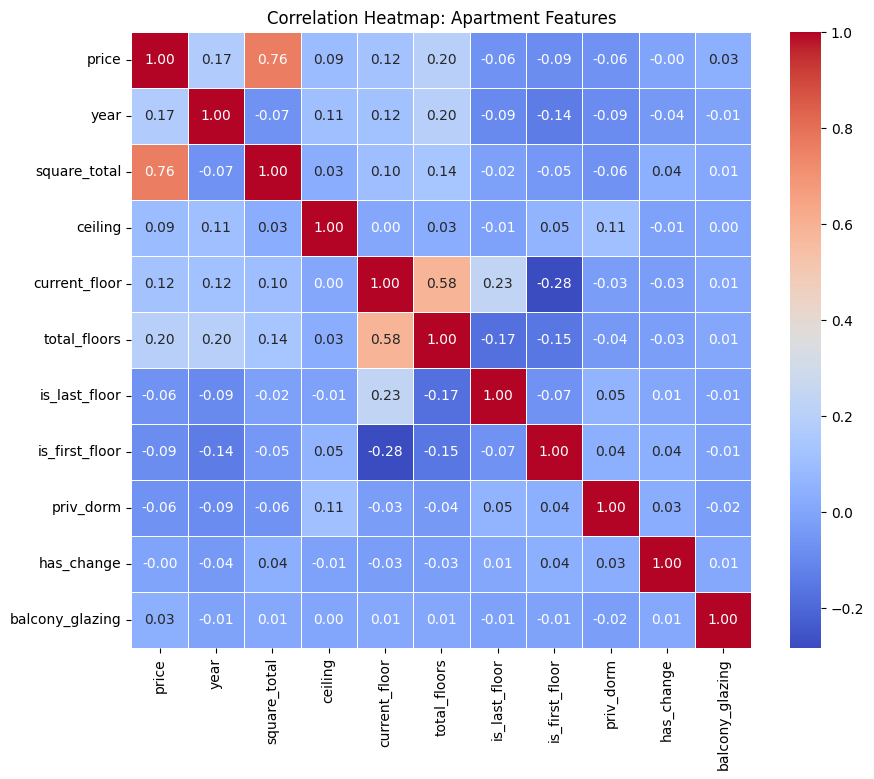

In [1343]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select only the numeric and boolean columns we created
# (Assuming your target column is named 'price')
cols_to_plot = [
    'price', 'year', 'square_total', 'ceiling', 'current_floor', 'total_floors', 
    'is_last_floor', 'is_first_floor', 
    'priv_dorm', 'has_change', 'balcony_glazing',
]

# 2. Calculate the correlation matrix
# Only include columns that actually exist in your df
existing_cols = [c for c in cols_to_plot if c in df.columns]
corr_matrix = df[existing_cols].corr()

# 3. Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,          # Show the numbers in the boxes
    cmap='coolwarm',     # Red for positive, Blue for negative
    fmt=".2f",           # Limit to 2 decimal places
    linewidths=0.5       # Add thin lines between boxes
)

plt.title('Correlation Heatmap: Apartment Features')

In [1344]:
df[[
    'price', 'year', 'square_total', 'ceiling', 'current_floor', 'total_floors', 
    'is_last_floor', 'is_first_floor', 
    'priv_dorm', 'has_change', 'balcony_glazing',
]].isnull().sum()

price              0
year               0
square_total       0
ceiling            0
current_floor      0
total_floors       0
is_last_floor      0
is_first_floor     0
priv_dorm          0
has_change         0
balcony_glazing    0
dtype: int64

In [1345]:
df['renovation'] = df['renovation'].fillna('не указан')

# Quick check of the new landscape
print("Renovation distribution after filling:")
print(df['renovation'].value_counts())

Renovation distribution after filling:
renovation
не указан                         4782
свежий ремонт                     2171
не новый, но аккуратный ремонт    1129
черновая отделка                   682
требует ремонта                    120
свободная планировка                34
Name: count, dtype: int64


In [1346]:
df[[
 'building',
 'complex',
 'parking',
 'toilet',
 'balcony',
 'door',
 'internet',
 'furniture',
 'flooring',
 'security',
 'renovation',
 'balcony_glazing',
 'phone',
 'current_floor',
 'total_floors',
 'is_last_floor',
 'is_first_floor',
 'square_total']].isnull().sum()

building            322
complex            1268
parking            2409
toilet             3329
balcony            4068
door               4618
internet           6024
furniture             0
flooring           4698
security           4615
renovation            0
balcony_glazing       0
phone              7025
current_floor         0
total_floors          0
is_last_floor         0
is_first_floor        0
square_total          0
dtype: int64

In [1347]:
# df['security'] = df['security'].fillna('не указан')
# security_dummies = df['security'].str.get_dummies(sep=', ')
# if 'не указан' in security_dummies.columns:
#     security_dummies = security_dummies.drop(columns=['не указан'])
# security_dummies = security_dummies.add_prefix('security_')
# df = pd.concat([df, security_dummies.astype(bool)], axis=1)
# print(df.columns)

In [1348]:
df['parking'] = df['parking'].fillna('не указан')
parking_mapping = {
    'гараж': 1,
    'рядом охраняемая стоянка': 2,
    'не указан': 3,
    'паркинг': 3,
}

df['parking_score'] = df['parking'].map(parking_mapping)

df.head()

,url,room,square,city,price,lat,lon,building,complex,year,...,priv_dorm,balcony,balcony_glazing,phone,current_floor,total_floors,is_last_floor,is_first_floor,square_total,parking_score
0,https://krisha.kz/a/show/1009899858,2,44.7 м²,Астана,36500000,51.104732,71.433500,монолитный,Asylym Park 1,2024,...,False,NaN,True,NaN,3,9,False,False,44.7,3
1,https://krisha.kz/a/show/1010109609,1,35 м²,Астана,22000000,51.085355,71.464394,монолитный,Jetisu.Aqsu,2025,...,False,NaN,True,NaN,7,12,False,False,35.0,3
2,https://krisha.kz/a/show/1007059972,3,"83 м², Площадь кухни — 11 м²",Астана,52500000,51.093737,71.425457,монолитный,Promenade Expo,2016,...,False,лоджия,True,NaN,4,18,False,False,83.0,3
3,https://krisha.kz/a/show/1009260622,1,"40 м², Площадь кухни — 12 м²",Астана,20000000,51.111827,71.538890,кирпичный,Safar,2024,...,False,NaN,True,NaN,1,9,False,True,40.0,3
4,https://krisha.kz/a/show/1010171334,1,"40 м², Площадь кухни — 12 м²",Астана,29300000,51.105840,71.389565,монолитный,Arena Style,2026,...,False,лоджия,True,отдельный,2,9,False,False,40.0,3


In [1349]:
fur_mapping = {
    'без мебели': 1,
    'частично': 2,
    'не указан': 2,
    'полностью': 3,
}

df['furniture_score'] = df['furniture'].map(fur_mapping)

df.head()

,url,room,square,city,price,lat,lon,building,complex,year,...,balcony,balcony_glazing,phone,current_floor,total_floors,is_last_floor,is_first_floor,square_total,parking_score,furniture_score
0,https://krisha.kz/a/show/1009899858,2,44.7 м²,Астана,36500000,51.104732,71.433500,монолитный,Asylym Park 1,2024,...,NaN,True,NaN,3,9,False,False,44.7,3,3
1,https://krisha.kz/a/show/1010109609,1,35 м²,Астана,22000000,51.085355,71.464394,монолитный,Jetisu.Aqsu,2025,...,NaN,True,NaN,7,12,False,False,35.0,3,2
2,https://krisha.kz/a/show/1007059972,3,"83 м², Площадь кухни — 11 м²",Астана,52500000,51.093737,71.425457,монолитный,Promenade Expo,2016,...,лоджия,True,NaN,4,18,False,False,83.0,3,2
3,https://krisha.kz/a/show/1009260622,1,"40 м², Площадь кухни — 12 м²",Астана,20000000,51.111827,71.538890,кирпичный,Safar,2024,...,NaN,True,NaN,1,9,False,True,40.0,3,2
4,https://krisha.kz/a/show/1010171334,1,"40 м², Площадь кухни — 12 м²",Астана,29300000,51.105840,71.389565,монолитный,Arena Style,2026,...,лоджия,True,отдельный,2,9,False,False,40.0,3,1


In [1350]:
reno_mapping = {
    'требует ремонта': 1,
    'свободная планировка': 2,
    'черновая отделка': 2,
    'не указан': 3,
    'не новый, но аккуратный ремонт': 4,
    'свежий ремонт': 5
}

df['renovation_score'] = df['renovation'].map(reno_mapping)

df.head()

,url,room,square,city,price,lat,lon,building,complex,year,...,balcony_glazing,phone,current_floor,total_floors,is_last_floor,is_first_floor,square_total,parking_score,furniture_score,renovation_score
0,https://krisha.kz/a/show/1009899858,2,44.7 м²,Астана,36500000,51.104732,71.433500,монолитный,Asylym Park 1,2024,...,True,NaN,3,9,False,False,44.7,3,3,5
1,https://krisha.kz/a/show/1010109609,1,35 м²,Астана,22000000,51.085355,71.464394,монолитный,Jetisu.Aqsu,2025,...,True,NaN,7,12,False,False,35.0,3,2,3
2,https://krisha.kz/a/show/1007059972,3,"83 м², Площадь кухни — 11 м²",Астана,52500000,51.093737,71.425457,монолитный,Promenade Expo,2016,...,True,NaN,4,18,False,False,83.0,3,2,3
3,https://krisha.kz/a/show/1009260622,1,"40 м², Площадь кухни — 12 м²",Астана,20000000,51.111827,71.538890,кирпичный,Safar,2024,...,True,NaN,1,9,False,True,40.0,3,2,3
4,https://krisha.kz/a/show/1010171334,1,"40 м², Площадь кухни — 12 м²",Астана,29300000,51.105840,71.389565,монолитный,Arena Style,2026,...,True,отдельный,2,9,False,False,40.0,3,1,3


In [1351]:
df['building'] = df['building'].fillna('не указан')
building_mapping = {
    'иной': 1,
    'не указан': 1,
    'панельный': 2,
    'кирпичный': 3,
    'монолитный': 4,
}

df['building_score'] = df['building'].map(building_mapping)

df.head()

,url,room,square,city,price,lat,lon,building,complex,year,...,phone,current_floor,total_floors,is_last_floor,is_first_floor,square_total,parking_score,furniture_score,renovation_score,building_score
0,https://krisha.kz/a/show/1009899858,2,44.7 м²,Астана,36500000,51.104732,71.433500,монолитный,Asylym Park 1,2024,...,NaN,3,9,False,False,44.7,3,3,5,4
1,https://krisha.kz/a/show/1010109609,1,35 м²,Астана,22000000,51.085355,71.464394,монолитный,Jetisu.Aqsu,2025,...,NaN,7,12,False,False,35.0,3,2,3,4
2,https://krisha.kz/a/show/1007059972,3,"83 м², Площадь кухни — 11 м²",Астана,52500000,51.093737,71.425457,монолитный,Promenade Expo,2016,...,NaN,4,18,False,False,83.0,3,2,3,4
3,https://krisha.kz/a/show/1009260622,1,"40 м², Площадь кухни — 12 м²",Астана,20000000,51.111827,71.538890,кирпичный,Safar,2024,...,NaN,1,9,False,True,40.0,3,2,3,3
4,https://krisha.kz/a/show/1010171334,1,"40 м², Площадь кухни — 12 м²",Астана,29300000,51.105840,71.389565,монолитный,Arena Style,2026,...,отдельный,2,9,False,False,40.0,3,1,3,4


In [1352]:
flooring_map = {
    'линолеум': 1,
    'дерево': 1,      # Merged due to similarly low medians
    'ковролан': 2,
    'пробковый': 2,
    'ламинат': 3,
    'плитка': 3,
    'паркет': 4       # The clear winner in value
}

df['flooring_score'] = df['flooring'].map(flooring_map).fillna(3)

In [1353]:
toilet_map = {
    'совмещенный': 1,
    'раздельный': 1,
    '2 с/у и более': 3,
}

df['toilet_scoring'] = df['toilet'].map(toilet_map).fillna(2)
df['toilet'].value_counts(dropna=False)

toilet
совмещенный      3416
NaN              3329
2 с/у и более    1261
раздельный        910
нет                 2
Name: count, dtype: int64

In [1354]:
balcony_map = {
    'балкон': 1,
    'лоджия': 2,
    'балкон и лоджия': 3,
    'несколько балконов или лоджий': 3  # Merged because 3+ units usually hit a price plateau
}

# Apply mapping and fill NaNs with 0 (representing "No balcony" or "Standard/Unknown")
df['balcony_score'] = df['balcony'].map(balcony_map).fillna(2).astype(int)

In [1355]:
door_map = {
    'деревянная': 1,
    'металлическая': 1,  # Merged because medians were nearly identical
    'бронированная': 2
}

# Fill NaNs with 1 (assuming standard/basic door)
df['door_score'] = df['door'].map(door_map).fillna(1).astype(int)

In [1356]:
df.columns

Index(['url', 'room', 'square', 'city', 'price', 'lat', 'lon', 'building',
       'complex', 'year', 'floor', 'renovation', 'toilet', 'door', 'internet',
       'parking', 'furniture', 'flooring', 'ceiling', 'security', 'has_change',
       'priv_dorm', 'balcony', 'balcony_glazing', 'phone', 'current_floor',
       'total_floors', 'is_last_floor', 'is_first_floor', 'square_total',
       'parking_score', 'furniture_score', 'renovation_score',
       'building_score', 'flooring_score', 'toilet_scoring', 'balcony_score',
       'door_score'],
      dtype='str')

/var/folders/zh/hmpvjk_x02n7scqlxvp07dym0000gn/T/ipykernel_11986/948717358.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], x=col, y='price', data=df, palette='viridis', showfliers=False)
/var/folders/zh/hmpvjk_x02n7scqlxvp07dym0000gn/T/ipykernel_11986/948717358.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], x=col, y='price', data=df, palette='viridis', showfliers=False)
/var/folders/zh/hmpvjk_x02n7scqlxvp07dym0000gn/T/ipykernel_11986/948717358.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i],

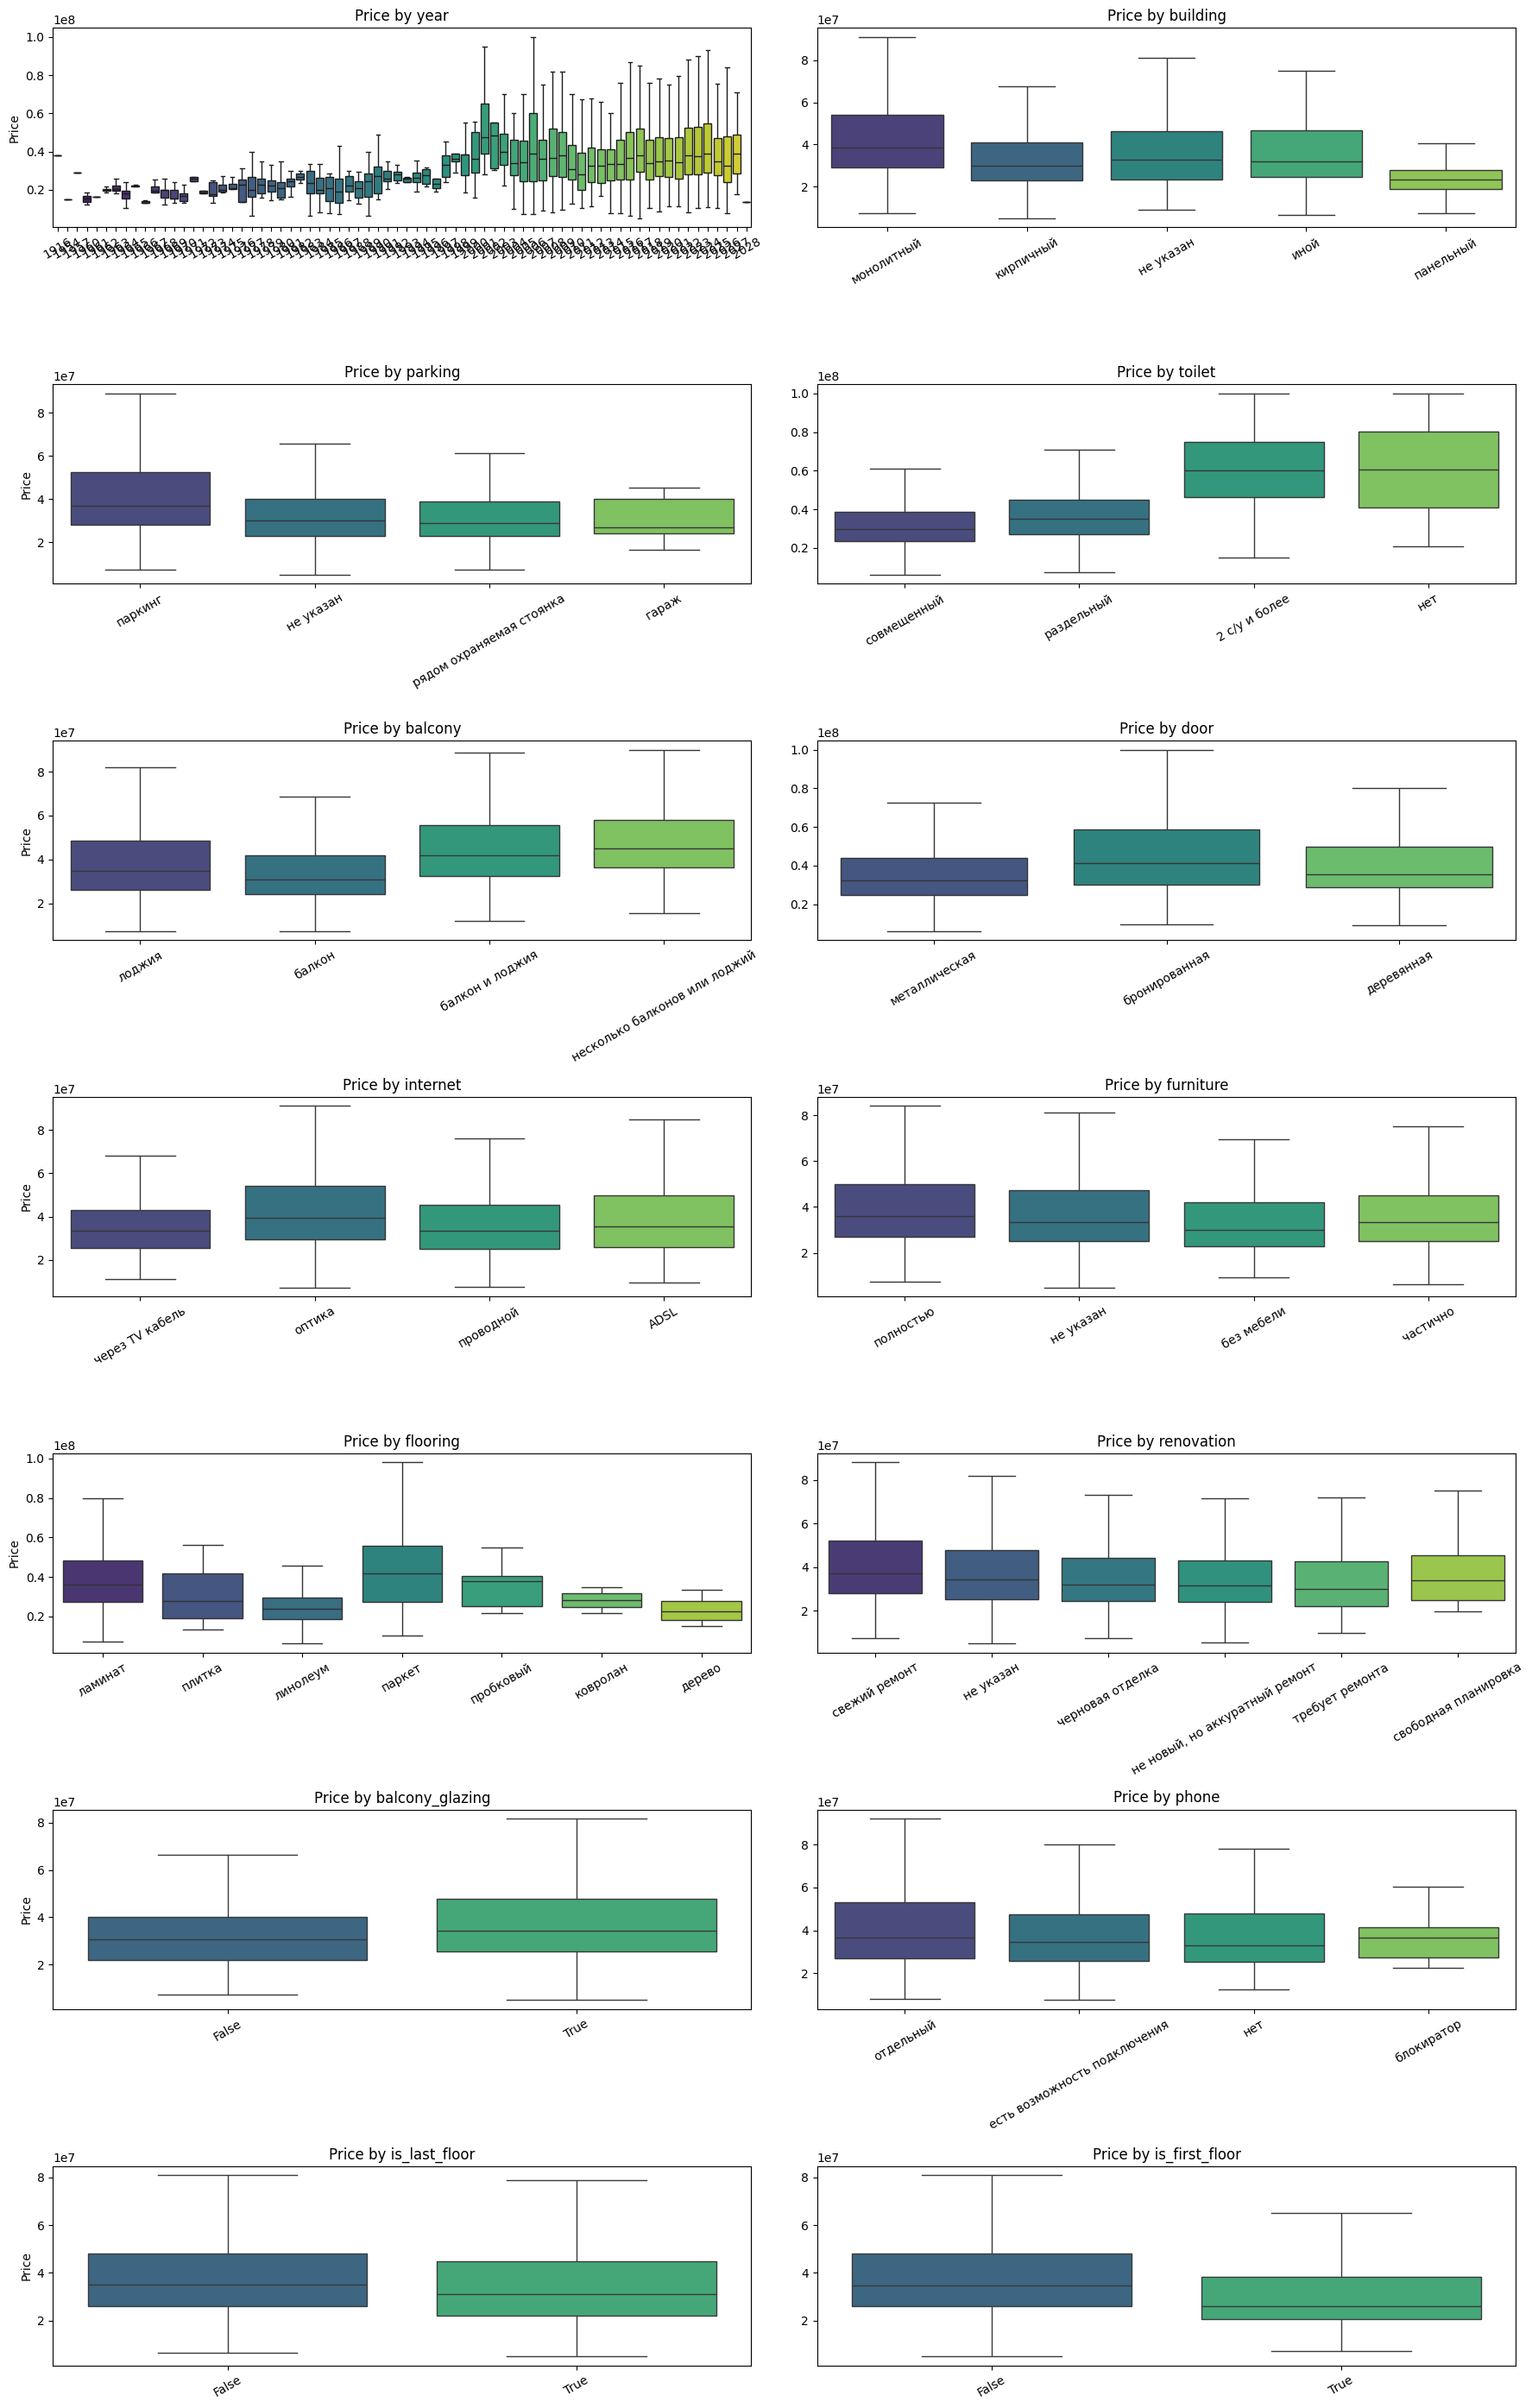

In [1357]:
# --- CELL: Categorical Impact on Price (Box Plots) ---
import seaborn as sns
import matplotlib.pyplot as plt
import math

# 1. Define the list of categorical columns you want to analyze
categorical_cols = [
    'year',
    'building',
    'parking',
    'toilet',
    'balcony',
    'door',
    'internet',
    'furniture',
    'flooring',
    'renovation',
    'balcony_glazing',
    'phone',
    'is_last_floor',
    'is_first_floor',
]

n_cols = 2  # Number of charts per row
n_rows = math.ceil(len(categorical_cols) / n_cols)

# 2. Create the Figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()  # Flatten to iterate easily

# 3. Loop and Plot
for i, col in enumerate(categorical_cols):
    sns.boxplot(ax=axes[i], x=col, y='price', data=df, palette='viridis', showfliers=False)
    
    axes[i].set_title(f'Price by {col}', fontsize=12)
    axes[i].tick_params(axis='x', rotation=30) # Reduced rotation for compactness
    axes[i].set_xlabel('') # Remove redundant x-labels to save space
    axes[i].set_ylabel('Price' if i % n_cols == 0 else '') # Only show Y label on left charts

# 4. Clean up empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [1358]:
df['floor_ratio'] = df['current_floor'] / df['total_floors']

/Users/oljk/Projects/real-estate-analyzer/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


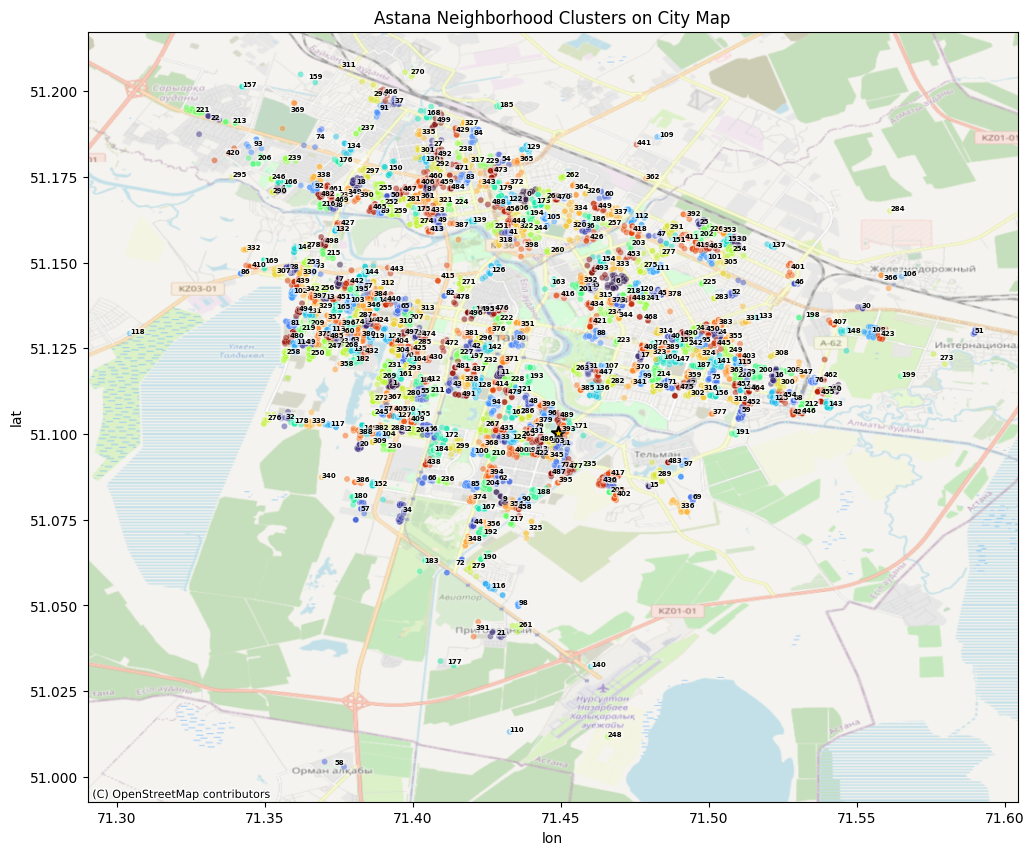

Success! Your input is in Cluster 393.


In [1359]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import contextily as cx # <--- New library for backgrounds

# --- 1. SET INPUT COORDINATES ---
# Example: Somewhere near the Khan Shatyr or Expo
input_lat = 51.100371
input_lon = 71.449204

# input_lat = 51.171502
# input_lon = 71.429980

# 1-3. Standard Clustering (Assuming your df is loaded)
astana_mask = (df['lat'].between(51.0, 51.3)) & (df['lon'].between(71.3, 71.6))
df_astana = df[astana_mask].copy()
coords_only = df_astana[['lat', 'lon']]

kmeans = KMeans(n_clusters=500, n_init=10, random_state=42)
df_astana['neighborhood_cluster'] = kmeans.fit_predict(coords_only)


# Find which cluster the input belongs to
input_point = np.array([[input_lat, input_lon]])
predicted_cluster = kmeans.predict(input_point)[0]


# 4. Plotting with Map Background
fig, ax = plt.subplots(figsize=(12, 10))

# Plot the scatter points
sns.scatterplot(
    ax=ax,
    data=df_astana, 
    x='lon', y='lat', 
    hue='neighborhood_cluster', 
    palette='turbo', 
    alpha=0.5, s=20, legend=None
)

# Plot Cluster Centers
centers = kmeans.cluster_centers_
# ax.scatter(centers[:, 1], centers[:, 0], c='red', marker='x', s=40, label='Centers')

# HIGHLIGHT THE INPUT LOCATION
ax.scatter(
    input_lon, input_lat, 
    c='gold', marker='*', s=100, edgecolor='black', linewidth=1.5,
    # label=f'Input Location', zorder=20
)

# ADD ASTANA BACKGROUND
# crs='EPSG:4326' tells contextily your data is in standard Lat/Lon
cx.add_basemap(ax, crs='EPSG:4326', source=cx.providers.OpenStreetMap.Mapnik, alpha=0.7)

# Label the clusters
for i, center in enumerate(centers):
    ax.text(center[1], center[0], str(i), fontsize=5, fontweight='bold', 
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.1'))

ax.set_title('Astana Neighborhood Clusters on City Map')
plt.show()

# Create the price per m2 column
df_astana['price_per_m2'] = df_astana['price'] / df_astana['square_total']

# Group by the cluster and calculate the mean
cluster_stats = df_astana.groupby('neighborhood_cluster')['price_per_m2'].mean()

# Map it back to the dataframe so every row knows its cluster's average
df['cluster_avg_price_m2'] = df_astana['neighborhood_cluster'].map(cluster_stats)

print(f"Success! Your input is in Cluster {predicted_cluster}.")

Text(0.5, 1.0, 'Correlation Heatmap: Apartment Features')

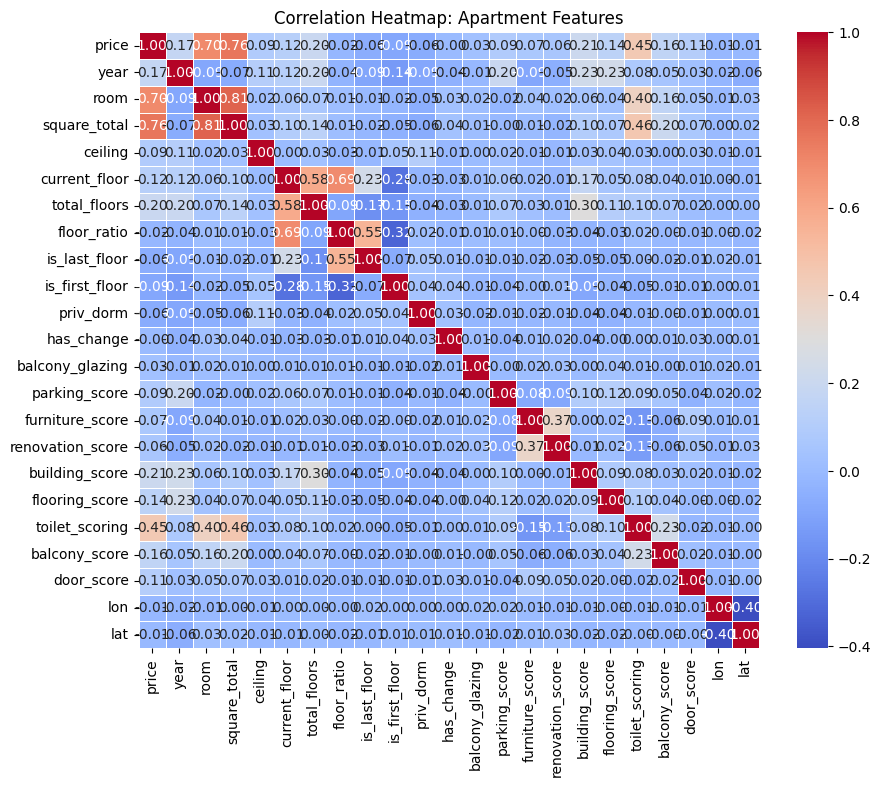

In [1360]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select only the numeric and boolean columns we created
# (Assuming your target column is named 'price')
cols_to_plot = [
    'price', 'cluster_avg_price', 'year', 'room', 'square_total', 'ceiling', 'current_floor', 'total_floors', 'floor_ratio',
    'is_last_floor', 'is_first_floor', 
    'priv_dorm', 'has_change', 'balcony_glazing', 'parking_score', 'furniture_score', 'renovation_score',
       'building_score', 'flooring_score', 'toilet_scoring', 'balcony_score',
       'door_score', 'lon', 'lat'
]

"""'url', 'room', 'square', 'city', 'price', 'building', 'complex', 'year',
       'floor', 'parking', 'ceiling', 'priv_dorm', 'has_change', 'toilet',
       'balcony', 'door', 'internet', 'furniture', 'flooring', 'security',
       'renovation', 'balcony_glazing', 'phone', 'current_floor',
       'total_floors', 'is_last_floor', 'is_first_floor', 'square_total', 'lon', 'lat'
       ]
"""

# 2. Calculate the correlation matrix
# Only include columns that actually exist in your df
existing_cols = [c for c in cols_to_plot if c in df.columns]
corr_matrix = df[existing_cols].corr()

# 3. Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,          # Show the numbers in the boxes
    cmap='coolwarm',     # Red for positive, Blue for negative
    fmt=".2f",           # Limit to 2 decimal places
    linewidths=0.5       # Add thin lines between boxes
)

plt.title('Correlation Heatmap: Apartment Features')

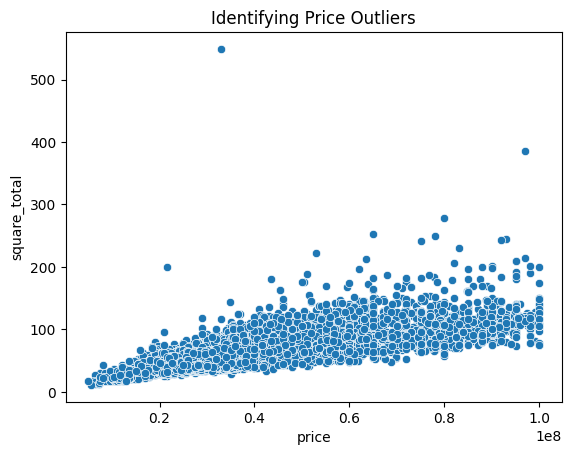

In [1361]:
sns.scatterplot(x=df['price'], y=df['square_total'])

plt.title('Identifying Price Outliers')
plt.show()

In [1362]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

cols_to_train = [
    'price', 'year', 'room', 'square_total', 'ceiling', 'total_floors', 'floor_ratio',
    'is_last_floor', 'is_first_floor', 'parking_score', 'furniture_score', 'renovation_score',
    'building_score', 'flooring_score', 'toilet_scoring', 'balcony_score',
    'door_score', 'cluster_avg_price_m2'
]

# 1. Setup Features and Target
# Ensure 'price' is excluded from X and used as Y
X = df[cols_to_train].drop(columns=['price'])
# Apply log transformation to the target to handle the large price scale
y_log = np.log1p(df['price']) 

# 2. Handle missing values (Standard LinearRegression cannot have NaNs)
X = X.fillna(X.median())

# 3. Train/Test Split
# We use y_log here so the model learns on a smaller, normalized scale
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# 4. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train the Model
model = LinearRegression()
model.fit(X_train_scaled, y_train_log)

# 6. Make Predictions (these will be in log scale)
y_pred_log = model.predict(X_test_scaled)

# 7. Convert predictions back to actual KZT safely
# Clip log values to avoid infinity during exponentiation
y_pred_log_clipped = np.clip(y_pred_log, 0, 25) 
y_pred_actual = np.expm1(y_pred_log_clipped)

# Convert actual test values back to KZT for MAE calculation
y_test_actual = np.expm1(y_test_log)

# 8. Evaluate Performance
# R2 is calculated on the log scale (standard practice for logged targets)
print(f"R2 Score: {r2_score(y_test_log, y_pred_log):.4f}")
# MAE is calculated on real KZT so you can understand the error in money
print(f"Mean Absolute Error: {mean_absolute_error(y_test_actual, y_pred_actual):,.0f} KZT")

R2 Score: 0.8531
Mean Absolute Error: 5,505,722 KZT


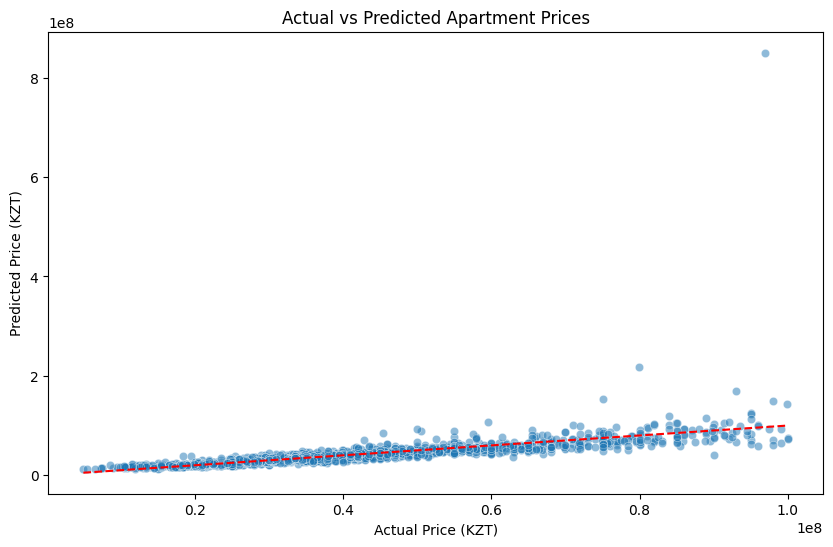

In [1363]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_actual, y=y_pred_actual, alpha=0.5)
plt.plot([y_test_actual.min(), y_test_actual.max()], [y_test_actual.min(), y_test_actual.max()], 'r--')
plt.xlabel('Actual Price (KZT)')
plt.ylabel('Predicted Price (KZT)')
plt.title('Actual vs Predicted Apartment Prices')
plt.show()

In [1372]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Initialize (n_estimators=100 is a good starting point)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Train (Using the same scaled data from before)
rf_model.fit(X_train_scaled, y_train_log)

# 3. Predict and Evaluate
y_pred_log_rf = rf_model.predict(X_test_scaled)
y_pred_rf = np.expm1(y_pred_log_rf)

# Calculate Scores
r2 = r2_score(y_test_log, y_pred_log_rf)
mae = mean_absolute_error(y_test_actual, y_pred_rf)
mse = mean_squared_error(y_test_actual, y_pred_rf)
rmse = np.sqrt(mse) # RMSE is simply the square root of MSE

print(f"Random Forest R2 Score: {r2:.4f}")
print(f"Random Forest MAE:      {mae:,.0f} KZT")
print(f"Random Forest RMSE:     {rmse:,.0f} KZT")

Random Forest R2 Score: 0.9243
Random Forest MAE:      3,811,981 KZT
Random Forest RMSE:     5,793,152 KZT


<Axes: title={'center': 'Feature Importance'}>

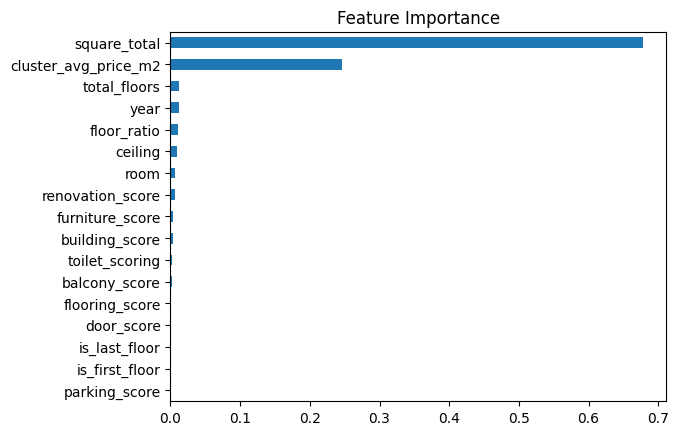

In [1365]:
import pandas as pd

importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', title='Feature Importance')

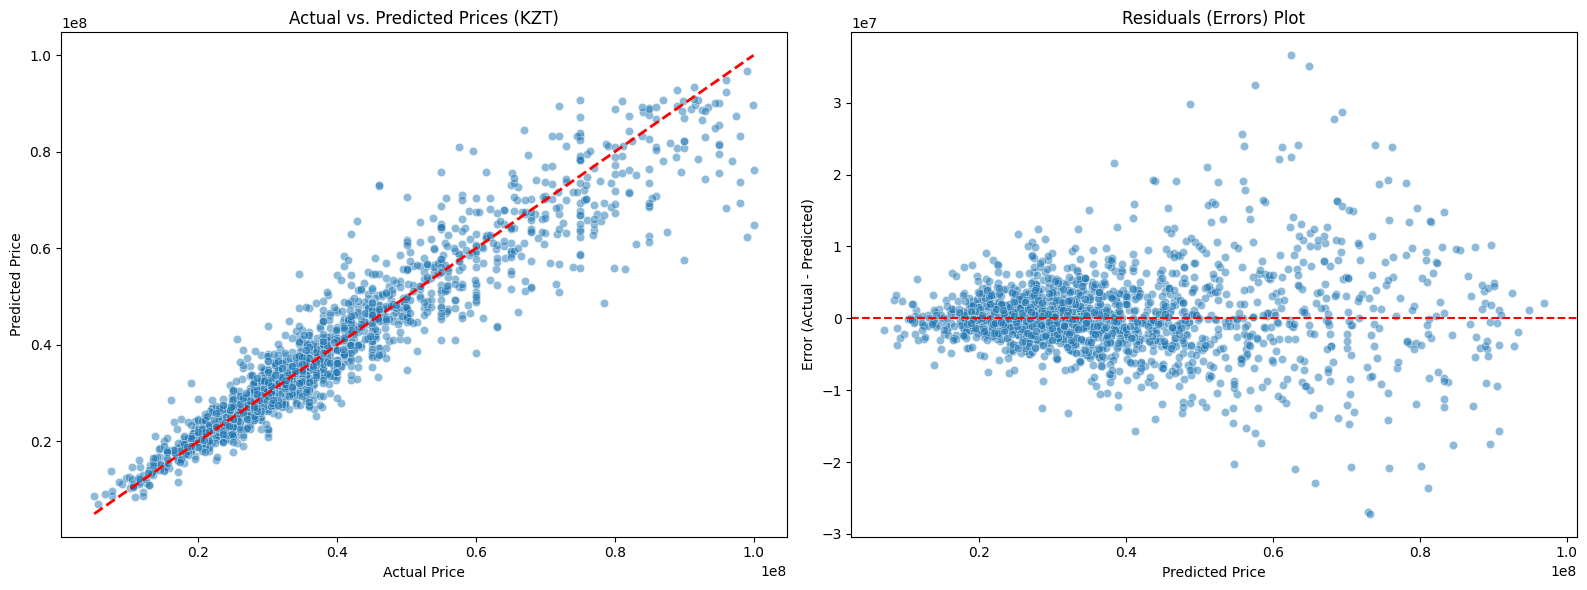

In [1366]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get Predictions (ensure they are back in real KZT)
y_pred_log_rf = rf_model.predict(X_test_scaled)
y_pred_rf = np.expm1(y_pred_log_rf)
y_test_real = np.expm1(y_test_log)

# 2. Create the Figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Actual vs Predicted
sns.scatterplot(x=y_test_real, y=y_pred_rf, alpha=0.5, ax=ax1)
ax1.plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'r--', lw=2)
ax1.set_title('Actual vs. Predicted Prices (KZT)')
ax1.set_xlabel('Actual Price')
ax1.set_ylabel('Predicted Price')

# Plot 2: Residuals (The "Misses")
residuals = y_test_real - y_pred_rf
sns.scatterplot(x=y_pred_rf, y=residuals, alpha=0.5, ax=ax2)
ax2.axhline(0, color='r', linestyle='--')
ax2.set_title('Residuals (Errors) Plot')
ax2.set_xlabel('Predicted Price')
ax2.set_ylabel('Error (Actual - Predicted)')

plt.tight_layout()
plt.show()

In [1367]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

# 1. Define the parameter grid
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [500, 1000],
    'subsample': [0.8]
}

# 2. Initialize the XGBoost Regressor
xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# 3. Setup the Grid Search
grid_search = GridSearchCV(
    estimator=xgb_reg, 
    param_grid=param_grid, 
    cv=3,           # 3-fold cross-validation
    scoring='r2',   # Optimize for R-squared
    verbose=1
)

# 4. Fit to your scaled training data
grid_search.fit(X_train_scaled, y_train_log)

# 5. Get the best model
best_xgb = grid_search.best_estimator_

print(f"Best Parameters: {grid_search.best_params_}")

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best Parameters: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 1000, 'subsample': 0.8}


In [1373]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# 1. Initialize the XGBoost Regressor
# Adjusting hyperparameters to be conservative and prevent overfitting
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)

# 2. Train the model
# We use the log-transformed target (y_train_log) for better stability
xgb_model.fit(X_train_scaled, y_train_log)

# 3. Predict
y_pred_log_xgb = xgb_model.predict(X_test_scaled)

# 4. Inverse transform to actual KZT
y_pred_xgb = np.expm1(y_pred_log_xgb)
y_test_actual = np.expm1(y_test_log)

# 5. Calculate Metrics
r2_xgb = r2_score(y_test_log, y_pred_log_xgb)
mae_xgb = mean_absolute_error(y_test_actual, y_pred_xgb)
mse_xgb = mean_squared_error(y_test_actual, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)

print(f"XGBoost R2 Score: {r2_xgb:.4f}")
print(f"XGBoost MAE:      {mae_xgb:,.0f} KZT")
print(f"XGBoost RMSE:     {rmse_xgb:,.0f} KZT")

XGBoost R2 Score: 0.9296
XGBoost MAE:      3,739,464 KZT
XGBoost RMSE:     5,569,924 KZT


In [1369]:
import pandas as pd
import numpy as np

def predict_my_flat(features_dict, model, scaler, training_columns):
    # 1. Convert dictionary to DataFrame
    input_df = pd.DataFrame([features_dict])
    
    # 2. Reorder columns to match the training set exactly
    feature_cols = [c for c in training_columns if c != 'price']
    input_df = input_df[feature_cols]
    
    # 3. Scale the features using your PREVIOUSLY fit scaler
    input_scaled = scaler.transform(input_df)
    
    # 4. Predict (results are in Log scale)
    log_prediction = model.predict(input_scaled)
    
    # 5. Inverse Log-transform to get KZT
    actual_price = np.expm1(log_prediction)[0]
    
    return actual_price

# --- EXAMPLE USAGE ---

# 2. Update your dictionary to be "Safe"
# Instead of recalculating the mean inside the dict, use the variable we just made
target_cluster = 393
avg_price_for_this_spot = cluster_stats.get(target_cluster, df_astana['price_per_m2'].mean())

# Define your flat's stats
# Seifullina
# my_flat = {
#     'square_total': 121.0,
#     'room': 4,
#     'ceiling': 3.0,
#     'year': 2006,
#     'total_floors': 10,
#     'floor_ratio': 0.9,       # (e.g., 6th floor of 12)
#     'building_score': 1,      # Monolith/Elite
#     'furniture_score': 3,     # Fully furnished
#     'renovation_score': 4,    # Modern/Euro
#     'toilet_scoring': 3,      # 2 bathrooms
#     'balcony_score': 3,
#     'door_score': 1,
#     'flooring_score': 3,      # Laminate/Parquet
#     'parking_score': 3,       # Has parking
#     'is_last_floor': 0,
#     'is_first_floor': 0,
#     'neighborhood_cluster': target_cluster,
#     'cluster_avg_price_m2': avg_price_for_this_spot # Use the pre-calculated value,
# }

# Al-Farabi
my_flat = {
    'square_total': 53.0,
    'room': 2,
    'ceiling': 3.0,
    'year': 2024,
    'total_floors': 12,
    'floor_ratio': 0.5,       # (e.g., 6th floor of 12)
    'building_score': 3,      # Monolith/Elite
    'furniture_score': 3,     # Fully furnished
    'renovation_score': 5,    # Modern/Euro
    'toilet_scoring': 2,      # 2 bathrooms
    'balcony_score': 2,
    'door_score': 1,
    'flooring_score': 3,      # Laminate/Parquet
    'parking_score': 3,       # Has parking
    'is_last_floor': 0,
    'is_first_floor': 0,
    'neighborhood_cluster': target_cluster,
    'cluster_avg_price_m2': avg_price_for_this_spot # Use the pre-calculated value,
}

# Get the price
predicted_price = predict_my_flat(my_flat, xgb_model, scaler, cols_to_train)

print(f"Estimated Market Value: {predicted_price:,.0f} KZT")

Estimated Market Value: 50,190,032 KZT
